# Test Infomap
Here we try to implement a function to compute the Infomap description length, tested with the previously created Test networks!

Side note: [This](https://python.igraph.org/en/latest/tutorials/cluster_contraction.html) might be useful!

In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import timeit
import warnings

# the helper functions are located in the src folder
import sys
sys.path.append("..")
from src.utils import visual_community_colors, generate_sbm
import src.map_equation as meq

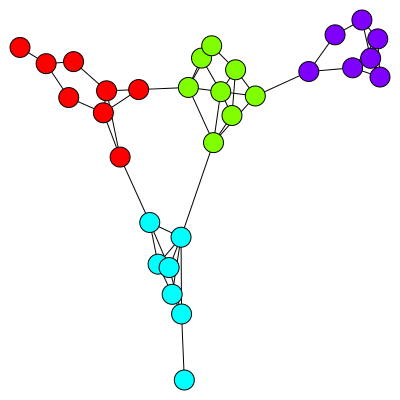

In [2]:
# load test networks
g1 = ig.Graph.Read_GraphML("../test_graphs/unweighted_undirected.graphml")
ig.plot(g1, **visual_community_colors(g1))

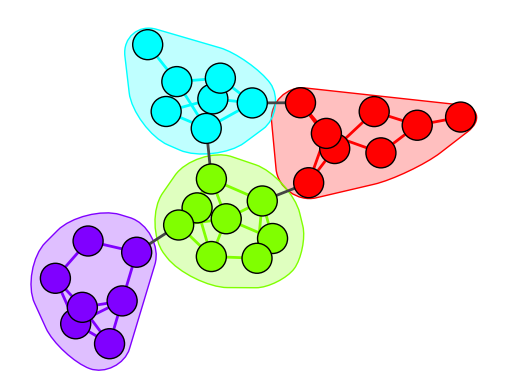

In [3]:
communities = ig.VertexClustering.FromAttribute(g1, "community")

num_communities = len(communities)
palette = ig.RainbowPalette(n=num_communities)
for i, community in enumerate(communities):
    g1.vs[community]["color"] = i   # Remove this to keep the original colors
    community_edges = g1.es.select(_within=community)
    community_edges["color"] = i

fig, ax = plt.subplots()
ig.plot(
    communities,
    target=ax,
    mark_groups=True,
    palette=palette
)
plt.show()

## Computing the description length
For the given test network with the given partitioning into communities, let's compute the description length as defined by the Map equation!
... which means we need the node visit frequencies etc. So, for our 4 cases:
- *unweighted, undirected*: node visit frequency = relative node degree? = degree(node)/2*|E| ??
- *weighted, undirected*: node visit frequency = relative weight of links connected to the node
$$ = \frac{w(\text{links connected to node})}{2\cdot w(\text{all links in network})}
$$
With directed networks, things get more complicated - need teleportation probability $\tau$, estimate ergodic node visit frequencies via power iteration method (see PageRank algorithm)

Let's test everything with the test networks we created previously:

In [4]:
g1 = ig.Graph.Read_GraphML("../test_graphs/unweighted_undirected.graphml")
communities1 = g1.community_infomap()
print('custom: ', meq.compute_description_length(g1, communities1.membership))
print('igraph: ', communities1.codelength)

custom:  3.4015829735877707
igraph:  3.40158297358777


In [5]:
g2 = ig.Graph.Read_GraphML("../test_graphs/weighted_undirected.graphml")
communities2 = g2.community_infomap(edge_weights="weight")
print('custom: ', meq.compute_description_length(g2, communities2.membership))
print('igraph: ', communities2.codelength)

custom:  3.3367124727600905
igraph:  3.336712472760091


In [6]:
g3 = ig.Graph.Read_GraphML("../test_graphs/unweighted_directed.graphml")
communities3 = g3.community_infomap()
print('custom: ', meq.compute_description_length(g3, communities3.membership))
print('igraph: ', communities3.codelength)

custom:  3.754023006412406
igraph:  3.5158296117409074


In [7]:
g4 = ig.Graph.Read_GraphML("../test_graphs/weighted_directed.graphml")
communities4 = g4.community_infomap()
print('custom: ', meq.compute_description_length(g4, communities4.membership))
print('igraph: ', communities4.codelength)

custom:  3.484882007293405
igraph:  3.3960631013011633


As you can see, the results for the directed networks don't really match. This may be because igraph is actually using a smart teleportation scheme that takes the node strength into account instead of just uniformly teleporting. 

### Updating for single-node movement
For performing the greedy search later, it is useful to have a function that updates the description length if one node is moved from one community to another. Since not all terms need to be recomputed, it should be more efficient to do an update than to recompute from scratch. 

Checking the exit flow update function:

In [8]:
# Benchmarking exit flow computation
# check if it's faster to update the exit flow with update_exit_flow()
# or just recompute from scratch with compute_exit_flow

# build a directed test graph
g_test = generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=True, weighted=True)
communities = g_test.vs["community"]

p = meq.pagerank(np.array(g_test.get_adjacency(attribute="weight").data), tau=0.15)
exit_flow = meq.compute_exit_flow(g_test, communities, p)

node = 2
comm_src = communities[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1

communities_new = communities.copy()
communities_new[node] = comm_trg
exit_flow_updated = meq.update_exit_flow(g_test, communities, p, exit_flow, node, comm_src, comm_trg)
exit_flow_recomputed = meq.compute_exit_flow(g_test, communities_new, p)

print("exit_flow_old:", exit_flow)
print("exit_flow_updated:", exit_flow_updated)
print("exit_flow_recomputed:", exit_flow_recomputed)
print("max difference:", np.max(np.abs(exit_flow_updated - exit_flow_recomputed)))

# simple timing benchmark
n_trials = 10000
t_update = timeit.timeit(lambda: meq.update_exit_flow(g_test, communities, p, exit_flow, node, comm_src, comm_trg), number=n_trials)
t_recompute = timeit.timeit(lambda: meq.compute_exit_flow(g_test, communities_new, p), number=n_trials)
print(f"update_exit_flow: {t_update:.6f}s for {n_trials} runs")
print(f"compute_exit_flow: {t_recompute:.6f}s for {n_trials} runs")


exit_flow_old: [0.02864617 0.03217964 0.02820352 0.03096783]
exit_flow_updated: [0.03490769 0.03962303 0.02820352 0.03096783]
exit_flow_recomputed: [0.03490769 0.03962303 0.02820352 0.03096783]
max difference: 6.938893903907228e-18
update_exit_flow: 10.650331s for 10000 runs
compute_exit_flow: 17.151296s for 10000 runs


Testing the new exit weight update function:

In [9]:
# Benchmarking exit flow computation
# check if it's faster to update the exit flow with update_exit_flow()
# or just recompute from scratch with compute_exit_flow

# build a directed test graph
g_test = generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=False, weighted=True)
communities = g_test.vs["community"]
exit_weights = meq.compute_exit_weights(g_test, communities)

node = 2
comm_src = communities[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1

communities_new = communities.copy()
communities_new[node] = comm_trg
exit_weights_updated = meq.update_exit_weights(g_test, communities, exit_weights, node, comm_src, comm_trg)
exit_weights_recomputed = meq.compute_exit_weights(g_test, communities_new)

print("exit_weights_old:", exit_weights)
print("exit_weights_updated:", exit_weights_updated)
print("exit_weights_recomputed:", exit_weights_recomputed)
print("max difference:", np.max(np.abs(exit_weights_updated - exit_weights_recomputed)))

# simple timing benchmark
n_trials = 10000
t_update = timeit.timeit(lambda: meq.update_exit_weights(g_test, communities, exit_weights, node, comm_src, comm_trg), number=n_trials)
t_recompute = timeit.timeit(lambda: meq.compute_exit_weights(g_test, communities_new), number=n_trials)
print(f"update_exit_weights: {t_update:.6f}s for {n_trials} runs")
print(f"compute_exit_weights: {t_recompute:.6f}s for {n_trials} runs")


exit_weights_old: [ 6.72775539  9.07274325  9.94535033 11.79507312]
exit_weights_updated: [ 9.62755083 11.97253869  9.94535033 11.79507312]
exit_weights_recomputed: [ 9.62755083 11.97253869  9.94535033 11.79507312]
max difference: 1.7763568394002505e-15
update_exit_weights: 7.446108s for 10000 runs
compute_exit_weights: 8.329578s for 10000 runs


... so currently the update function for the exit_flows is actually slower than the full recomputation, but that might change for a larger graph.

TODO: time for larger graph!!!

Testing the full update function for single-node moves on the test networks:

In [10]:
# Check the update
Ls_diff = []
n_trials = 10000
for _ in range(n_trials):

    # build a directed test graph
    g = generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=False, weighted=False)
    communities_old = g.vs["community"]

    node = 2
    comm_src = communities[node]
    if comm_src != 0:
        comm_trg = 0
    else:
        comm_trg = 1

    communities_new = communities_old.copy()
    communities_new[node] = comm_trg
    L, p_old, p_mod_old, exit_weights, scalars = meq.compute_description_length(g, communities_old, returnTerms=True)

    # now let's try to merge communities
    L_recomputed = meq.compute_description_length(g, communities_new) # recompute from scratch
    L_updated = meq.update_node_move_description_length(g, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg, scalars_old=scalars) # update existing

    Ls_diff.append(L_recomputed - L_updated)


print("max difference:", np.max(np.abs(Ls_diff)))

max difference: 1.7763568394002505e-15


Undirected, unweighted:

In [11]:
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities1.membership)
node = 2
comm_src = communities_old[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1
communities_new = communities_old.copy()
communities_new[node] = comm_trg
L, p_old, p_mod_old, exit_weights, scalars = meq.compute_description_length(g1, communities_old, returnTerms=True)

# now let's try to merge communities
L_merged_1 = meq.compute_description_length(g1, communities_new) # recompute from scratch
L_merged_2 = meq.update_node_move_description_length(g1, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg, scalars_old=scalars) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.602281651664555
updated:  3.6022816516645557


Undirected, weighted:

In [12]:

# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities2.membership)
node = 2
comm_src = communities_old[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1
communities_new = communities_old.copy()
communities_new[node] = comm_trg
L, p_old, p_mod_old, exit_weights, scalars = meq.compute_description_length(g2, communities_old, returnTerms=True)

# now let's try to move a node between communities
L_merged_1 = meq.compute_description_length(g2, communities_new) # recompute from scratch
L_merged_2 = meq.update_node_move_description_length(g2, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg, scalars_old=scalars) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.7017317618840218
updated:  3.701731761884022


In [13]:
%timeit -n100 -r50 L_merged_1 = meq.compute_description_length(g2, communities_new) # recompute from scratch

The slowest run took 9.08 times longer than the fastest. This could mean that an intermediate result is being cached.
696 μs ± 353 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)


In [14]:
%timeit -n100 -r50 L_merged_2 = meq.update_node_move_description_length(g2, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg, scalars_old=scalars) # update existing

255 μs ± 65 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)


So the update function is faster than the full recompute!

Directed, unweighted:

In [15]:
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities3.membership)
node = 2
comm_src = communities_old[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1
communities_new = communities_old.copy()
communities_new[node] = comm_trg
L, p_old, p_mod_old, exit_weights, scalars = meq.compute_description_length(g3, communities_old, returnTerms=True)
num_communities = len(p_mod_old)
node_counts_old = np.bincount(communities_old, minlength=num_communities)

# now let's try to merge communities
L_merged_1 = meq.compute_description_length(g3, communities_new) # recompute from scratch
L_merged_2 = meq.update_node_move_description_length(g3, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg, node_counts_old=node_counts_old, scalars_old=scalars) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.8747504625842093
updated:  3.8747504625842093


Directed, weighted:

In [16]:
# precompute the old description length with additional terms, and new communities
communities_old = np.array(communities4.membership)
node = 2
comm_src = communities[node]
if comm_src != 0:
    comm_trg = 0
else:
    comm_trg = 1
communities_new = communities_old.copy()
communities_new[node] = comm_trg
L, p_old, p_mod_old, exit_weights, scalars = meq.compute_description_length(g4, communities_old, returnTerms=True)
num_communities = len(p_mod_old)
node_counts_old = np.bincount(communities_old, minlength=num_communities)

# now let's try to merge communities
L_merged_1 = meq.compute_description_length(g4, communities_new) # recompute from scratch
L_merged_2 = meq.update_node_move_description_length(g4, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg, node_counts_old=node_counts_old, scalars_old=scalars) # update existing

print('From scratch: ',L_merged_1)
print('updated: ', L_merged_2)

From scratch:  3.6576404042839155
updated:  3.6576404042839146


In [17]:
%timeit -n100 -r50 L_merged_1 = meq.compute_description_length(g4, communities_new) # recompute from scratch

19.8 ms ± 3.89 ms per loop (mean ± std. dev. of 50 runs, 100 loops each)


In [18]:
%timeit -n100 -r50 L_merged_2 = meq.update_node_move_description_length(g4, communities_old, p_old, p_mod_old, exit_weights, node, comm_trg, node_counts_old=node_counts_old, scalars_old=scalars) # update existing
 # update existing

320 μs ± 90 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)


Here the difference between update and recompute is A LOT bigger than in the undirected case, interestingly.